# Development of Dream Analysis Website Using the AI-DLC



This project develops a dream analysis website guided by the AI-Driven Development Lifecycle (AI-DLC), covering three core phases: Inception, Construction and Operation. During the Inception phase, AI assists in requirement confirmation and solution design. In the Construction phase, core functions including AI-powered dream interpretation are built with prompt engineering and RAG, while CI/CD pipeline based on GitHub Actions is configured to realize automated code inspection, unit testing, Docker packaging and continuous delivery.

## 1. Environment Setup & LLM Client Initialization


In [8]:
import os
import sys
# Add the parent directory to sys.path so we can import the 'utils' module
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import all needed utilities at once
from utils import (
    load_environment,
    get_completion,
    setup_llm_client,
    clean_llm_output,
    recommended_models_table,
)

# Ensure Pillow (used for diagram rendering) is installed
try:
    from PIL import Image  # noqa: F401
    print("✅ Pillow already installed")
except ImportError:
    print("Installing Pillow...")
    %pip install pillow
    from PIL import Image  # re-import after installation

# Load environment variables (e.g., API keys from .env file)
load_environment()

# Initialize the LLM client – model can be configured via environment variable
MODEL_NAME = os.getenv("LLM_MODEL", "openai/gpt-5.2")

try:
    client, model_name, api_provider = setup_llm_client(MODEL_NAME)
    print(f"✅ LLM Client initialized: {api_provider} - {model_name}")
except Exception as e:
    print(f"❌ Error initializing LLM client: {e}")
    raise   # Stop execution if the LLM client cannot be created

✅ Pillow already installed
✅ LLM Client configured: Using 'apifree' with model 'openai/gpt-5.2'
✅ LLM Client initialized: apifree - openai/gpt-5.2


# Phase 1: Inception


I will be driven by the (1) problem, (2) personas, (3) requirements, and (4) user stories.

### 1.1 Defining the Business Problem (Human-Written)

In [10]:
problem = """
Build a Freudian dream interpretation website with the following workflow:

1. A user submits a detailed dream description (free text).
2. The system generates exactly 5–7 open-ended follow‑up questions based on Freudian theory.
   These questions should probe symbols, repressed desires, childhood memories, and emotional conflicts.
3. The user answers all questions in a guided form.
4. The system then produces:
   - A full dream interpretation (manifest vs latent content, wish fulfillment, etc.)
   - An assessment of the user's current psychological state, highlighting possible unconscious conflicts.
   - Personalized mental well‑being suggestions.
5. All dream data (description, questions, answers, analysis) are stored per user session
   and can be reviewed later.

The interface should guide the user through these steps in a smooth, step-by-step manner
(e.g., a single-page application with progressive disclosure).
The tone must feel therapeutic, professional, and use appropriate Freudian vocabulary.
"""

### 1.2 AI-Generated Problem Statement

In [11]:
if client and 'problem' in globals():
    print("--- Generating Problem Statement ---")
    prompt = (
        "Read the business problem below and produce a single, concise problem statement.\n"
        "The statement MUST start with 'Design and develop a website that...' and explicitly mention:\n"
        "- Freudian dream interpretation\n"
        "- Multi-step interaction (dream input → follow-up questions → analysis)\n"
        "- Storage of user sessions for later review\n\n"
        f"Business Problem:\n{problem}"
    )
    problem_statement = get_completion(
        prompt, client, model_name, api_provider, temperature=0.2
    )
    print(problem_statement)
else:
    print("Skipping step because LLM client or business problem is not available.")

--- Generating Problem Statement ---
Design and develop a website that provides Freudian dream interpretation through a multi-step interaction (dream input → follow-up questions → analysis), generates 5–7 Freudian-theory-based open-ended questions, delivers a therapeutic interpretation and well-being suggestions, and stores user sessions (dream description, questions, answers, and analysis) for later review.


### 1.3 AI-Generated User Personas

In [12]:
if client and 'problem_statement' in globals():
    print("--- Generating Personas ---")
    prompt = (
           "Generate exactly 3 user personas for a Freudian dream interpretation website. "
        "Use the format below exactly:\n\n"
        "Personas: <one-sentence intro>\n\n"
        "1. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "2. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "3. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "Rules:\n"
        "- Use single role titles only; no slashes (/) or combined titles.\n"
        "- Keep each bullet concise (1-2 sentences).\n"
        "- The three roles must be: Dreamer, Freudian AI Analyst, and Administrator.\n"
        "- Incorporate Freudian terminology (e.g., latent content, wish fulfillment, unconscious conflict) in the descriptions.\n"
        "- The Dreamer needs a safe, therapeutic experience; the AI Analyst needs to probe deeply using psychoanalytic principles; "
        "the Administrator needs data management and compliance tools.\n\n"
        f"Problem Statement: {problem_statement}"
    )
    personas = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print(f"Personas: {personas}")
else:
    print("Skipping step because LLM client or problem statement is not available.")

--- Generating Personas ---
Personas: Personas: Three core users collaborate to capture dream material, explore latent content through psychoanalytic questioning, and manage sessions securely.

1. **Dreamer**
   - **Responsibilities:** Shares dream narratives and responds to 5–7 open-ended follow-up prompts to help surface latent content and possible unconscious conflict. Reviews interpretations and tracks recurring themes across saved sessions.
   - **Needs:** A safe, therapeutic experience with clear consent, privacy controls, and gentle framing around wish fulfillment and symbolism. Supportive well-being suggestions and the ability to revisit or delete past sessions.

2. **Freudian AI Analyst**
   - **Responsibilities:** Generates probing, Freudian-theory-based questions that differentiate manifest content from latent content and test hypotheses about wish fulfillment. Produces an interpretive summary and well-being suggestions grounded in psychoanalytic principles.
   - **Needs:** 

### 1.4 AI-Generated Product Requirements Document (PRD)

In [13]:
if client and 'problem_statement' in globals() and 'personas' in globals():
    print("--- Generating PRD ---")
    prompt = (
    
    "Write a comprehensive Product Requirements Document (PRD) in markdown. "
    "You MUST use exactly the following headings, each with 2-4 concise bullets:\n"
    "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
    "## Key Features\n## User Flows\n## Functional Requirements\n"
    "## Non-Functional Requirements\n## Constraints/Assumptions\n"
    "## Success Metrics\n## Open Questions\n\n"
    "Rules:\n"
    "- Use ONLY the headings listed above. No extra sections.\n"
    "- Keep each bullet to one or two sentences.\n"
    "- The PRD must describe a Freudian dream interpretation website.\n"
    "- Incorporate the following domain-specific details where relevant:\n"
    "  * Multi-step workflow: dream input → follow-up questions → analysis.\n"
    "  * Freudian concepts: latent content, wish fulfillment, free association.\n"
    "  * Data storage: user sessions that save dream, questions, answers, and analysis.\n"
    "  * Theraputic and professional tone in user-facing language.\n"
    f"Problem Statement: {problem_statement}\n"
    f"Personas: {personas}"

    )
    prd = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3,
    )
    prd = clean_llm_output(prd, language='markdown')
    print(f"PRD: {prd}")
    # Ensure artifacts directory exists
    os.makedirs('artifacts', exist_ok=True)
    # Save PRD as Markdown
    with open('artifacts/prd.md', 'w') as f:
        f.write(prd)
    print('✅ Saved: artifacts/prd.md')
else:
    print("Skipping step because LLM client, problem statement, or personas are not available.")

--- Generating PRD ---
PRD: ## Overview
- Build a Freudian dream interpretation website that guides users through a multi-step workflow: dream input → 5–7 open-ended follow-up questions → analysis.
- Use Freudian concepts (manifest vs. latent content, wish fulfillment, free association) to generate therapeutic, professional interpretations and well-being suggestions.
- Store user sessions containing the dream description, generated questions, user answers, and final analysis for later review, export, or deletion.
- Provide clear consent, privacy controls, and safety-oriented language that supports reflection without presenting as medical diagnosis.

## Goals
- Help Dreamers capture manifest dream material and explore latent content through guided free association questions.
- Generate a coherent Freudian interpretation emphasizing hypotheses about wish fulfillment and unconscious conflict, with practical well-being suggestions.
- Enable secure session persistence and retrieval so users

### 1.5 AI-Generated User Stories (JSON)

In [14]:
if client and 'prd' in globals():
    print("--- Generating User Stories ---")
    prompt = (
       "Return ONLY valid JSON with this schema:\n"
"{\n  \"user_stories\": [\n    {\n      \"id\": 1,\n      \"role\": \"<role>\",\n"
"      \"goal\": \"<goal>\",\n      \"benefit\": \"<benefit>\",\n"
"      \"acceptance_criteria\": [\"<criteria>\", \"<criteria>\"]\n    }\n  ]\n}\n\n"
"Rules:\n"
"- Provide exactly 6 user stories.\n"
"- Stories must cover the full multi-step Freudian dream interpretation workflow:\n"
"  1) Dream submission, 2) Generating follow‑up questions, 3) Answering questions,\n"
"  4) Receiving full analysis (interpretation, psychological assessment, suggestions),\n"
"  5) Reviewing past dream sessions, 6) Administration and session management.\n"
"- Use only the three personas from the PRD (Dreamer, Freudian AI Analyst, Administrator).\n"
"- Incorporate Freudian vocabulary where appropriate (manifest/latent content, wish fulfillment, etc.).\n"
"- Keep each field concise. No extra keys.\n"
f"PRD: {prd}"
    )
    user_stories = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    user_stories = clean_llm_output(user_stories, language='json')
    print(f"User Stories: {user_stories}")
    # Save user stories as JSON
    import json, os
    os.makedirs('artifacts', exist_ok=True)
    user_stories_data = { 'user_stories': user_stories }
    with open('artifacts/user_stories.json', 'w') as f:
        json.dump(user_stories_data, f, indent=2)
    print('✅ Saved: artifacts/user_stories.json')
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Generating User Stories ---
User Stories: {
  "user_stories": [
    {
      "id": 1,
      "role": "Dreamer",
      "goal": "submit a dream with consent, emotions, and tags to capture manifest content",
      "benefit": "my session starts safely and is ready for interpretation",
      "acceptance_criteria": [
        "I can enter dream text, date/emotions/tags, and confirm privacy/consent before submitting",
        "On submit, a new session is created and saved with my dream narrative as manifest material"
      ]
    },
    {
      "id": 2,
      "role": "Freudian AI Analyst",
      "goal": "generate 5–7 open-ended follow-up questions using free association prompts",
      "benefit": "I can probe latent content and possible wish fulfillment without leading or diagnosing",
      "acceptance_criteria": [
        "The system produces exactly 5–7 questions tailored to the dream and optional prior-session themes",
        "Questions use Freudian vocabulary where relevant (e.g., manife

## Phase 2: Construction
 AI-Assisted Design & Implementation

### 2.1 AI-Generated UML Use Case Diagram

--- Generating PlantUML Use Case Diagram ---
Generated PlantUML diagram:
@startuml
actor Dreamer
actor "Freudian AI Analyst" as FreudianAIAnalyst
actor Administrator

rectangle "Freudian Dream Interpretation System" {
  usecase "Submit dream" as SubmitDream
  usecase "Generate follow-up questions" as GenerateQuestions
  usecase "Answer follow-up questions" as AnswerQuestions
  usecase "Deliver full analysis" as DeliverAnalysis
  usecase "Review past sessions" as ReviewSessions
  usecase "Manage session data" as ManageData
  usecase "Administer secure storage" as AdminStorage
}

Dreamer -- SubmitDream
Dreamer -- AnswerQuestions
Dreamer -- ReviewSessions
Dreamer -- ManageData

FreudianAIAnalyst -- GenerateQuestions
FreudianAIAnalyst -- DeliverAnalysis

Administrator -- AdminStorage

SubmitDream ..> GenerateQuestions : <<include>>
GenerateQuestions ..> AnswerQuestions : <<include>>
AnswerQuestions ..> DeliverAnalysis : <<include>>

ReviewSessions ..> ManageData : <<extend>>
@enduml
✅ Save

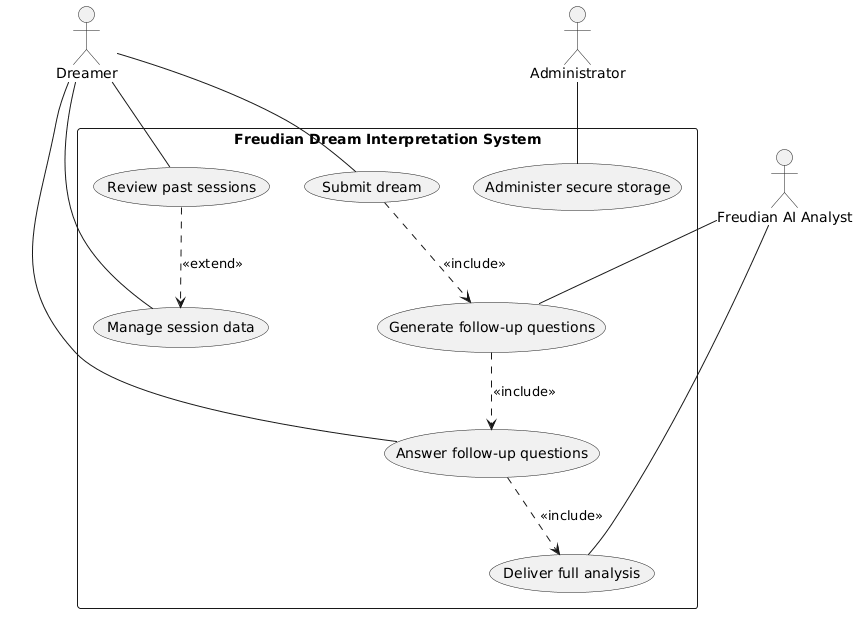

In [15]:
from utils import render_plantuml_diagram
import os

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Use Case Diagram ---")
    prompt = (
        "Generate a UML-compliant PlantUML use case diagram based on the user stories below.\n"
        "Use standard UML notation and PlantUML syntax.\n\n"
        "Required structure:\n"
        "@startuml\n"
        "actor ActorName\n"
        "actor AnotherActor\n\n"
        "rectangle \"Freudian Dream Interpretation System\" {\n"
        "  usecase \"Use Case Name\" as UC1\n"
        "  usecase \"Another Use Case\" as UC2\n"
        "}\n\n"
        "ActorName -- UC1\n"
        "AnotherActor -- UC2\n"
        "@enduml\n\n"
        "UML Rules:\n"
        "- Actors must be defined using the `actor` keyword and placed outside the system boundary.\n"
        "- The system boundary must be a `rectangle` with the name: \"Freudian Dream Interpretation System\".\n"
        "- Use cases must be defined using the `usecase` keyword and placed inside the system boundary.\n"
        "- Associations between actors and use cases must use `--` (undirected association), not arrows.\n"
        "- Do NOT number use case names; use clear verb–noun phrases instead.\n"
        "- Extract unique actors from the `role` field in the user stories.\n"
        "- Create one use case per distinct `goal` field.\n"
        "- Keep use case names concise (max 5 words).\n"
        "- IMPORTANT: Model relationships based on the acceptance criteria:\n"
        "  * If a use case always involves another step (e.g., answering questions always triggers analysis), use `<<include>>` from the base use case to the included one.\n"
        "  * If a use case is optional or conditional (e.g., reviewing history, admin features), use `<<extend>>` from the base use case.\n"
        "  * For multi-step workflows like \"Submit Dream → Generate Questions → Answer Questions → View Analysis\", chain them with `<<include>>` relationships where appropriate.\n"
        "- Avoid layout directives unless necessary.\n"
        "- Return ONLY valid PlantUML code, with no explanations or commentary.\n\n"
        f"User Stories: {user_stories}"
    )
    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    puml = clean_llm_output(puml, language='text')
    print("Generated PlantUML diagram:")
    print(puml)
    
    # Save to file
    os.makedirs('artifacts/diagrams', exist_ok=True)
    with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
        f.write(puml)
    print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
    render_plantuml_diagram(puml, "artifacts/diagrams/use_case_diagram.png")
else:
    print("Skipping step because LLM client or user_stories is not available.")

### 2.2 AI-Generated UML Sequence Diagram

--- Generating PlantUML Sequence Diagram (dynamic) ---
Generated Sequence Diagram:
@startuml
actor "Dreamer" as Dreamer
participant "Frontend App" as FE
participant "Backend API" as BE
participant "LLM Analysis Service" as LLM
database "Session Database" as DB

Dreamer -> FE: Enter dream text/date/emotions/tags
Dreamer -> FE: Confirm privacy/consent
Dreamer -> FE: Submit dream
FE -> BE: Send dream submission data
BE -> DB: Save new session with manifest narrative
DB --> BE: Return session ID
BE --> FE: Return session created confirmation

FE -> BE: Request 5-7 follow-up questions for session
BE -> DB: Load session manifest content
DB --> BE: Return session data
BE -> LLM: Generate 5-7 open-ended follow-up questions
LLM --> BE: Return tailored questions
BE -> DB: Save questions to session
BE --> FE: Return questions for display
FE --> Dreamer: Show follow-up questions

@enduml
✅ Saved: artifacts/diagrams/sequence_diagram.puml
✅ Diagram rendered and saved to: artifacts\artifacts\diagrams

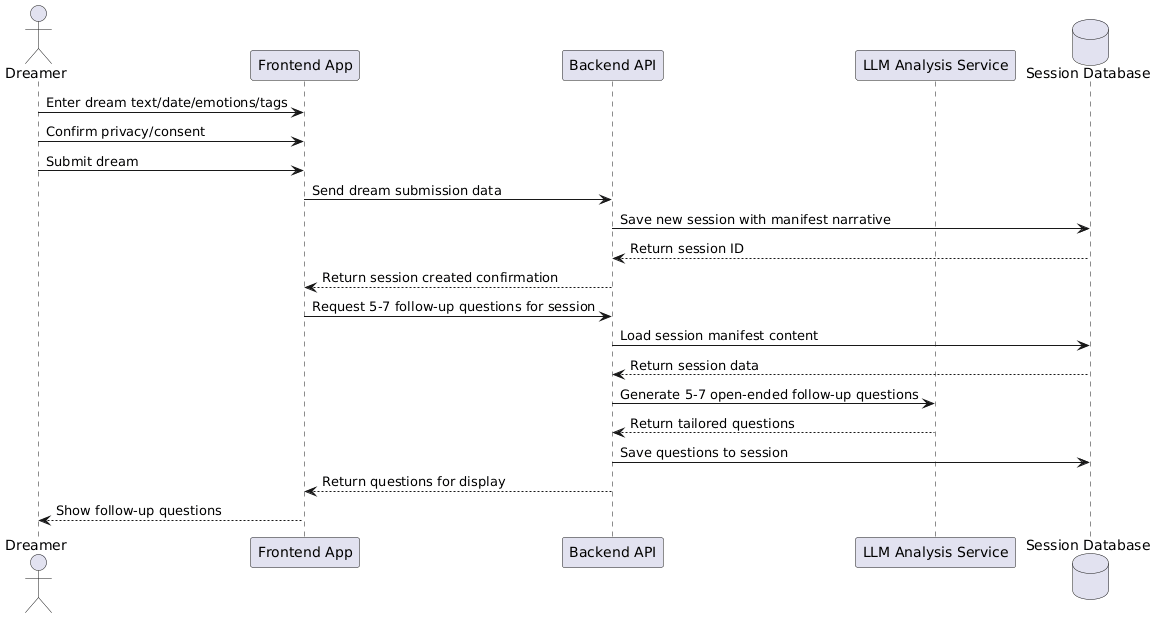

In [16]:
if client and 'user_stories' in globals():
    print("--- Generating PlantUML Sequence Diagram (dynamic) ---")
    prompt = (
        "Based on the following user stories, generate a UML sequence diagram in PlantUML format.\n"
        "The diagram should illustrate the main success scenario of the most critical user story, "
        "including all key interactions between the user and the system.\n\n"
        "Required UML syntax:\n"
        "@startuml\n"
        "actor \"ActorName\" as Actor\n"
        "participant \"ComponentName\" as Component\n"
        "database \"StorageName\" as DB\n"
        "Actor -> Component: Message\n"
        "Component --> Actor: Return message\n"
        "Component -> DB: Save data\n"
        "@enduml\n\n"
        "Rules:\n"
        "- Identify all unique human actors from the `role` field of user stories; define them with `actor`.\n"
        "- Identify system components (e.g., frontend, backend, LLM service) based on acceptance criteria; "
        "define them with `participant`.\n"
        "- If any story mentions data persistence (e.g., 'save', 'store', 'database'), include a `database` participant.\n"
        "- Construct a step‑by‑step flow that fulfills the acceptance criteria. Use solid arrows (`->`) for requests, "
        "dashed arrows (`-->`) for responses or asynchronous returns.\n"
        "- Include at least 5 interactions (arrows) that reflect the real workflow from the stories.\n"
        "- Label each arrow with a concise, verb‑phrase description (e.g., 'Submit dream text', 'Generate questions').\n"
        "- Do NOT invent steps that are not implied by the user stories (e.g., 'payment' if absent).\n"
        "- Return ONLY valid PlantUML code, with no extra commentary.\n\n"
        f"User Stories: {user_stories}"
    )

    seq_puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    seq_puml = clean_llm_output(seq_puml, language='text')
    print("Generated Sequence Diagram:")
    print(seq_puml)

    # Save to file
    os.makedirs('artifacts/diagrams', exist_ok=True)
    with open('artifacts/diagrams/sequence_diagram.puml', 'w') as f:
        f.write(seq_puml)
    print('✅ Saved: artifacts/diagrams/sequence_diagram.puml')
    render_plantuml_diagram(seq_puml, "artifacts/diagrams/sequence_diagram.png")
else:
    print("Skipping step because LLM client or user_stories is not available.")

#### 2.3 AI generated Code

In [17]:
if client and 'user_stories' in globals():
    import json, os

    print("--- Generating Dream Interpreter Flask App & Frontend ---")

    # ── 1. Build main.py line by line ──
    # Rule: lines containing a single-quote (') use double-quote outer strings,
    #        lines containing double-quotes (") use single-quote outer strings.
    main_py_lines = [
        "from flask import Flask, request, jsonify, send_from_directory",
        "from flask_cors import CORS",
        "import os, json, uuid, time, base64, requests",
        "",
        "# ── LLM / Image config (reads from env vars at runtime) ──",
        "API_KEY = os.environ.get('APIFREE_API_KEY', '')",
        "BASE_URL = os.environ.get('APIFREE_API_BASE', 'https://api.apifree.ai')",
        "TEXT_MODEL = os.environ.get('LLM_MODEL', 'openai/gpt-5.2')",
        "IMAGE_MODEL = 'qwen/qwen-image-2512'",
        "",
        "app = Flask(__name__)",
        "app.secret_key = os.environ.get('SECRET_KEY', os.urandom(24).hex())",
        "CORS(app)",
        "",
        "# ── Health check ──",
        "@app.route('/health')",
        "def health():",
        "    return jsonify({'status': 'ok'})",
        "",
        "# ── Generate dreamy illustration (cached to static/) ──",
        "@app.route('/generate_illustration')",
        "def generate_illustration():",
        "    cache_path = os.path.join('static', 'illustration.png')",
        "    if os.path.exists(cache_path):",
        "        return jsonify({'image_url': '/static/illustration.png'})",
        "    if not API_KEY:",
        "        return jsonify({'error': 'APIFREE_API_KEY not configured.'}), 500",
        "    try:",
        "        headers = {",
        "            'Authorization': f'Bearer {API_KEY}',",
        "            'Content-Type': 'application/json',",
        "        }",
        "        payload = {",
        "            'model': IMAGE_MODEL,",
        "            'prompt': (",
        "                'A dreamy, surreal, therapeutic illustration inspired by Freudian psychoanalysis. '",
        "                'Soft deep purple and midnight blue tones, floating symbols like keys, doors, '",
        "                'clouds, and stars. Ethereal atmosphere, abstract, calming, professional. '",
        "                'No text, no people, just dreamlike imagery.'",
        "            ),",
        "            'num_images': 1,",
        "            'width': 1024,",
        "            'height': 768,",
        "            'num_inference_steps': 50,",
        "        }",
        "        resp = requests.post(",
        "            f'{BASE_URL}/v1/image/submit',",
        "            headers=headers, json=payload, timeout=30",
        "        )",
        "        resp.raise_for_status()",
        "        submit_data = resp.json()",
        "        if submit_data.get('code') != 200:",
        "            return jsonify({'error': submit_data.get('code_msg', 'Submission failed')}), 500",
        "        request_id = submit_data['resp_data']['request_id']",
        "        for _ in range(60):",
        "            time.sleep(2)",
        "            check = requests.get(",
        "                f'{BASE_URL}/v1/image/{request_id}/result',",
        "                headers=headers, timeout=30",
        "            )",
        "            check.raise_for_status()",
        "            check_data = check.json()",
        "            status = check_data.get('resp_data', {}).get('status', '')",
        "            if status == 'success':",
        "                img_url = check_data['resp_data']['image_list'][0]",
        "                img_bytes = requests.get(img_url, timeout=30).content",
        "                os.makedirs('static', exist_ok=True)",
        "                with open(cache_path, 'wb') as f:",
        "                    f.write(img_bytes)",
        "                return jsonify({'image_url': '/static/illustration.png'})",
        "            if status in ('error', 'failed'):",
        "                return jsonify({'error': 'Image generation failed'}), 500",
        "        return jsonify({'error': 'Image generation timed out'}), 500",
        "    except Exception as e:",
        "        return jsonify({'error': f'Illustration failed: {str(e)}'}), 500",
        "",
        "# ── Freudian dream analysis ──",
        "@app.route('/analyze_dream', methods=['POST'])",
        "def analyze_dream():",
        "    data = request.get_json(silent=True) or {}",
        "    dream_text = (data.get('dream') or '').strip()",
        "    if not dream_text:",
        "        return jsonify({'error': 'Dream text cannot be empty.'}), 400",
        "    if not API_KEY:",
        "        return jsonify({'error': 'APIFREE_API_KEY not configured.'}), 500",
        "    try:",
        "        headers = {",
        "            'Authorization': f'Bearer {API_KEY}',",
        "            'Content-Type': 'application/json',",
        "        }",
        "        prompt = (",
        '            "You are a Freudian psychoanalyst. Analyze the following dream description. "',
        '            "Return ONLY valid JSON (no markdown, no extra text) with exactly 3 keys:\\n"',
        "            '  \"interpretation\": a detailed Freudian analysis covering manifest vs latent content,\\n'",
        "            '  \"psychological_state\": an assessment of the dreamer\\'s current psychological state,\\n'",
        "            '  \"suggestions\": a list of 3-5 therapeutic suggestions.\\n'",
        '            "Use Freudian concepts: wish fulfillment, repression, displacement, Oedipus complex, "',
        '            "free association, dream-work, condensation, secondary elaboration. "',
        '            "Maintain a professional, therapeutic tone. Avoid clinical diagnosis.\\n"',
        '            "\\n"',
        '            "Dream: " + dream_text',
        "        )",
        "        payload = {",
        "            'model': TEXT_MODEL,",
        "            'messages': [{'role': 'user', 'content': prompt}],",
        "            'max_tokens': 2048,",
        "            'temperature': 0.7,",
        "        }",
        "        resp = requests.post(",
        "            f'{BASE_URL}/v1/chat/completions',",
        "            headers=headers, json=payload, timeout=120",
        "        )",
        "        if not resp.ok:",
        "            return jsonify({'error': f'API error: {resp.status_code}'}), 500",
        "        data_resp = resp.json()",
        "        choices = data_resp.get('choices')",
        "        if not choices and isinstance(data_resp.get('resp_data'), dict):",
        "            choices = data_resp['resp_data'].get('choices')",
        "        if not choices:",
        "            return jsonify({'error': 'Unexpected API response format'}), 500",
        "        raw = choices[0].get('message', {}).get('content', '')",
        "        if isinstance(raw, list):",
        "            raw = ''.join(item.get('text', '') if isinstance(item, dict) else str(item) for item in raw)",
        "        raw = raw.strip()",
        "        if raw.startswith('```'):",
        "            raw = raw.split('\\n', 1)[-1].rsplit('\\n```', 1)[0].strip()",
        "        analysis = json.loads(raw)",
        "        if not isinstance(analysis.get('suggestions'), list):",
        "            analysis['suggestions'] = []",
        "        return jsonify(analysis)",
        "    except json.JSONDecodeError:",
        "        return jsonify({'error': 'Failed to parse AI response as JSON. Please try again.'}), 500",
        "    except Exception as e:",
        "        return jsonify({'error': f'Analysis failed: {str(e)}'}), 500",
        "",
        "# ── Frontend & static files ──",
        "@app.route('/')",
        "def serve_index():",
        "    return send_from_directory('static', 'index.html')",
        "",
        "@app.route('/static/<path:filename>')",
        "def serve_static(filename):",
        "    return send_from_directory('static', filename)",
        "",
        "if __name__ == '__main__':",
        "    os.makedirs('static', exist_ok=True)",
        "    app.run(host='0.0.0.0', port=5005, debug=True)",
    ]

    main_py_code = "\n".join(main_py_lines) + "\n"

    os.makedirs("artifacts/app/flask", exist_ok=True)
    with open("artifacts/app/flask/main.py", "w") as f:
        f.write(main_py_code)
    print("✅ Saved: artifacts/app/flask/main.py")

    # ── 2. Generate index.html via LLM ──
    html_prompt = (
        "Generate a complete single-page HTML5 app for a Freudian Dream Interpreter.\n"
        "Use Bootstrap 5 CDN. All CSS/JS inline.\n\n"
        "BACKEND API (use RELATIVE URLs like '/analyze_dream'):\n"
        "- GET /generate_illustration -> {image_url: '/static/illustration.png'}\n"
        "- POST /analyze_dream  body:{dream:string} -> {interpretation, psychological_state, suggestions:[string]}\n\n"
        "PAGE STRUCTURE:\n"
        "- Dark therapeutic theme: deep purple (#140a25), serif fonts, soft gradients, light text.\n"
        "- On page load: call /generate_illustration and display the returned image at the top.\n"
        "  If image fails, show a placeholder gradient (do NOT block the page).\n"
        "- Heading: 'Freudian Dream Interpreter'\n"
        "- Tagline: 'Explore the hidden meanings of your dreams'\n"
        "- A <textarea id='dreamInput'> placeholder='Describe your dream in detail...'\n"
        "- An 'Analyze' button (onclick='submitDream()')\n"
        "- A <div id='result'> for the analysis output\n"
        "- A loading spinner during fetch\n\n"
        "JAVASCRIPT submitDream():\n"
        "- Trim dream text; if empty show inline error (red text), return.\n"
        "- Show spinner, disable button.\n"
        "- fetch('/analyze_dream', {method:'POST', headers:{'Content-Type':'application/json'}, body:JSON.stringify({dream})})\n"
        "- On error: show error message in red inside #result.\n"
        "- On success: display Interpretation (h3+p), Psychological State (h3+p), Suggestions (h3+ul>li).\n"
        "- CRITICAL: NEVER use innerHTML with raw API data. Use textContent/createTextNode. Provide escapeHtml() helper.\n"
        "- Hide spinner, re-enable button after completion.\n\n"
        "RULES:\n"
        "- ALL fetch URLs relative. NEVER hardcode http://...\n"
        "- Return ONLY the complete HTML document. No markdown fences, no commentary.\n"
    )

    html_code = get_completion(
        html_prompt, client, model_name, api_provider, temperature=0.4
    )
    html_code = clean_llm_output(html_code, language="html")

    os.makedirs("artifacts/app/flask/static", exist_ok=True)
    with open("artifacts/app/flask/static/index.html", "w") as f:
        f.write(html_code)
    print("✅ Saved: artifacts/app/flask/static/index.html")

    # ── 3. Generate README ──
    readme_prompt = (
        "Write a short README.md (under 200 words) for a Freudian Dream Interpreter web app.\n"
        "Description: Flask app accepting dream text via POST /analyze_dream, using an LLM (via apifree) "
        "to return a Freudian analysis (interpretation, psychological state, suggestions). "
        "Also generates a dreamy illustration via /generate_illustration.\n"
        "Setup: pip install flask flask-cors requests\n"
        "Env vars required: APIFREE_API_KEY, APIFREE_API_BASE (optional), LLM_MODEL (optional, default openai/gpt-5.2)\n"
        "Run: python main.py -> http://127.0.0.1:5005\n"
        "Include curl example for POST /analyze_dream."
    )
    readme_content = get_completion(
        readme_prompt, client, model_name, api_provider, temperature=0.3
    )
    with open("artifacts/app/flask/README.md", "w") as f:
        f.write(readme_content)
    print("✅ Saved: artifacts/app/flask/README.md")

    print("\n✅ Dream Interpreter generated successfully!")
else:
    print("Skipping step because LLM client or user_stories is not available.")

--- Generating Dream Interpreter Flask App & Frontend ---
✅ Saved: artifacts/app/flask/main.py
✅ Saved: artifacts/app/flask/static/index.html
✅ Saved: artifacts/app/flask/README.md

✅ Dream Interpreter generated successfully!


### 2.5 AI-Generated Dependency List — requirements.txt

In [18]:
if client and os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating requirements.txt for Dream Interpreter ---")
    
    with open('artifacts/app/flask/main.py', 'r') as f:
        app_code = f.read()
    
    # Scan ALL lines for imports, not just the top block
    import_lines = []
    for line in app_code.split('\n'):
        stripped = line.strip()
        if stripped.startswith('import ') or stripped.startswith('from '):
            import_lines.append(stripped)
    
    imports_text = '\n'.join(import_lines)
    print(f"  Found {len(import_lines)} import statement(s)")
    
    requirements = get_completion(
        f"Based on these Python import statements, list all required pip-installable package "
        f"dependencies (one per line). Include only package names, no version constraints. "
        f"Remove duplicates and Python standard library modules (os, sys, json, uuid, time, "
        f"base64, re, pathlib, typing, collections, datetime, io). "
        f"Import statements:\n{imports_text}",
        client, model_name, api_provider, temperature=0.3
    )
    requirements = clean_llm_output(requirements, language='text')
    
    req_lines = [line.strip() for line in requirements.split('\n')]
    req_lines = [line for line in req_lines if line and not line.startswith('#')]
    req_set = set(req_lines)
    req_list = sorted(list(req_set))
    
    clean_requirements = '\n'.join(req_list)
    
    with open('artifacts/app/flask/requirements.txt', 'w') as f:
        f.write(clean_requirements)
    print(f'✅ Saved: artifacts/app/flask/requirements.txt ({len(req_list)} packages)')
    print(f"  Packages: {', '.join(req_list)}")
else:
    print("Skipping step because Flask app is not available.")

--- Generating requirements.txt for Dream Interpreter ---
  Found 3 import statement(s)
✅ Saved: artifacts/app/flask/requirements.txt (3 packages)
  Packages: flask, flask-cors, requests


## Phase 3: Operation


### 3.1 Dockerfile & .dockerignore (Human-Written)

In [25]:
import os

# Generate Dockerfile for the Dream Interpreter application
dockerfile_content = """FROM python:3.11-slim

# Set working directory
WORKDIR /app

# Copy requirements and install dependencies
COPY flask/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy application files
COPY flask/ .

# Create static directory for generated images
RUN mkdir -p static

# Expose port
EXPOSE 5005

# Set environment variables
ENV FLASK_APP=main.py
ENV FLASK_ENV=production

# Run the application
CMD ["python", "main.py"]
"""

# Generate .dockerignore file
dockerignore_content = """__pycache__
*.pyc
*.pyo
*.pyd
.Python
env/
venv/
.venv
.git
.gitignore
.env
.DS_Store
*.egg-info
dist
build
.pytest_cache
"""

# Generate docker-compose.yml for orchestration
docker_compose_content = """version: '3.8'

services:
  dream-interpreter:
    build:
      context: .
      dockerfile: docker/Dockerfile
    container_name: dream-interpreter
    ports:
      - "5005:5005"
    environment:
      - FLASK_ENV=production
      - FLASK_APP=main.py
      - APIFREE_API_KEY=${APIFREE_API_KEY}
      - APIFREE_API_BASE=${APIFREE_API_BASE:-https://api.apifree.ai}
      - LLM_MODEL=${LLM_MODEL:-openai/gpt-5.2}
    volumes:
      - ./flask:/app
    restart: unless-stopped
"""

# Create Docker configuration files
if os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating Docker Configuration Files ---")
    
    os.makedirs('artifacts/app/docker', exist_ok=True)
    
    with open('artifacts/app/docker/Dockerfile', 'w') as f:
        f.write(dockerfile_content)
    print('✅ Saved: artifacts/app/docker/Dockerfile')
    
    with open('artifacts/app/docker/.dockerignore', 'w') as f:
        f.write(dockerignore_content)
    print('✅ Saved: artifacts/app/docker/.dockerignore')
    
    with open('artifacts/app/docker-compose.yml', 'w') as f:
        f.write(docker_compose_content)
    print('✅ Saved: artifacts/app/docker-compose.yml')
    
    print("\n--- Docker Build & Run Instructions ---")
    print("""
To build and run the Docker container:

IMPORTANT: All commands must be run from the artifacts/app directory!

1. Navigate to the app directory:
   cd artifacts/app

2. Build the Docker image:
   docker build -t dream-interpreter:latest -f docker/Dockerfile .

3. Run the container (pass API key from your .env):
   docker run -p 5005:5005 \\
     -e APIFREE_API_KEY=%APIFREE_API_KEY% \\
     -e APIFREE_API_BASE=%APIFREE_API_BASE% \\
     -e LLM_MODEL=openai/gpt-5.2 \\
     dream-interpreter:latest

4. Alternative: Use Docker Compose (recommended, reads .env automatically):
   docker-compose up --build

5. Access the Dream Interpreter:
   Open http://127.0.0.1:5005 in your browser

6. View logs:
   docker logs -f dream-interpreter

7. Stop the container:
   docker stop dream-interpreter
   
8. Clean up:
   docker-compose down
    """)
    
    print("\nDocker containerization setup complete!")
else:
    print("Dream interpreter Flask app not found. Please run the code generation cell first.")

--- Generating Docker Configuration Files ---
✅ Saved: artifacts/app/docker/Dockerfile
✅ Saved: artifacts/app/docker/.dockerignore
✅ Saved: artifacts/app/docker-compose.yml

--- Docker Build & Run Instructions ---

To build and run the Docker container:

IMPORTANT: All commands must be run from the artifacts/app directory!

1. Navigate to the app directory:
   cd artifacts/app

2. Build the Docker image:
   docker build -t dream-interpreter:latest -f docker/Dockerfile .

3. Run the container (pass API key from your .env):
   docker run -p 5005:5005 \
     -e APIFREE_API_KEY=%APIFREE_API_KEY% \
     -e APIFREE_API_BASE=%APIFREE_API_BASE% \
     -e LLM_MODEL=openai/gpt-5.2 \
     dream-interpreter:latest

4. Alternative: Use Docker Compose (recommended, reads .env automatically):
   docker-compose up --build

5. Access the Dream Interpreter:
   Open http://127.0.0.1:5005 in your browser

6. View logs:
   docker logs -f dream-interpreter

7. Stop the container:
   docker stop dream-interp

### 4  Test and CI/CD

In [2]:
import os

print("--- Generating CI/CD Pipeline Configuration ---")

# ── 1. Test file ──
test_code = '''"""
Pytest tests for the Freudian Dream Interpreter Flask API.
Run: pytest test_app.py -v
"""
import json
from unittest.mock import patch, MagicMock
import main as app_module


def test_health():
    """GET /health returns 200 and status ok."""
    with app_module.app.test_client() as client:
        resp = client.get('/health')
        assert resp.status_code == 200
        assert resp.get_json() == {'status': 'ok'}


def test_analyze_dream_empty():
    """POST /analyze_dream with empty dream returns 400."""
    with app_module.app.test_client() as client:
        resp = client.post('/analyze_dream', json={})
        assert resp.status_code == 400
        assert 'error' in resp.get_json()


def test_analyze_dream_no_api_key():
    """POST /analyze_dream without API key returns 500."""
    with app_module.app.test_client() as client:
        resp = client.post('/analyze_dream', json={'dream': 'I was flying'})
        assert resp.status_code == 500


def test_analyze_dream_success():
    """POST /analyze_dream with mocked LLM response returns 200."""
    mock_response = MagicMock()
    mock_response.ok = True
    mock_response.json.return_value = {
        'choices': [{
            'message': {
                'content': json.dumps({
                    'interpretation': 'This dream reveals latent content about freedom.',
                    'psychological_state': 'The dreamer is experiencing mild anxiety.',
                    'suggestions': ['Keep a dream journal', 'Practice free association'],
                })
            }
        }]
    }

    with patch.dict('main.__dict__', {'API_KEY': 'test-key'}):
        with patch('main.requests.post', return_value=mock_response):
            with app_module.app.test_client() as client:
                resp = client.post('/analyze_dream',
                    json={'dream': 'I was flying over a dark ocean.'})
                assert resp.status_code == 200
                data = resp.get_json()
                assert 'interpretation' in data
                assert 'psychological_state' in data
                assert isinstance(data.get('suggestions'), list)


def test_generate_illustration_cached():
    """GET /generate_illustration when image exists returns image URL."""
    with app_module.app.test_client() as client:
        resp = client.get('/generate_illustration')
        assert resp.status_code == 200
        data = resp.get_json()
        assert 'image_url' in data or 'error' in data


def test_serve_index():
    """GET / returns the index.html page."""
    with app_module.app.test_client() as client:
        resp = client.get('/')
        assert resp.status_code in (200, 404)


def test_serve_static():
    """GET /static/illustration.png returns the image or 404."""
    with app_module.app.test_client() as client:
        resp = client.get('/static/illustration.png')
        assert resp.status_code in (200, 404)
'''

with open('artifacts/app/flask/test_app.py', 'w') as f:
    f.write(test_code)
print('✅ Saved: artifacts/app/flask/test_app.py')

# ── 2. GitHub Actions CI/CD workflow ──
workflow_yaml = '''name: CI/CD Pipeline

on:
  push:
    branches: [master, main]
  pull_request:
    branches: [master, main]

jobs:
  # ── CI: Test ──
  test:
    runs-on: ubuntu-latest
    defaults:
      run:
        working-directory: artifacts/app/flask

    steps:
      - name: Checkout code
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: '3.11'

      - name: Install dependencies
        run: |
          pip install --upgrade pip
          pip install flask flask-cors requests pytest

      - name: Run tests
        run: pytest test_app.py -v

  # ── CI: Build Docker image ──
  build:
    needs: test
    runs-on: ubuntu-latest
    defaults:
      run:
        working-directory: artifacts/app

    steps:
      - name: Checkout code
        uses: actions/checkout@v4

      - name: Build Docker image
        run: docker build -t dream-interpreter:latest -f docker/Dockerfile .

      - name: Verify container starts
        run: |
          docker run -d -p 5005:5005 \\
            -e APIFREE_API_KEY=fake-key \\
            -e LLM_MODEL=openai/gpt-5.2 \\
            --name test-container \\
            dream-interpreter:latest
          sleep 3
          curl -f http://localhost:5005/health || (docker logs test-container && exit 1)
          docker stop test-container
'''

os.makedirs('.github/workflows', exist_ok=True)
with open('.github/workflows/ci-cd.yml', 'w') as f:
    f.write(workflow_yaml)
print('✅ Saved: .github/workflows/ci-cd.yml')

print("\\n--- CI/CD Pipeline Overview ---")
print("""
CI/CD pipeline generated:

  .github/workflows/ci-cd.yml     — GitHub Actions workflow
  artifacts/app/flask/test_app.py — Pytest API tests

Pipeline stages:
  1. test  — Install deps, run pytest (mocks external LLM calls)
  2. build — Build Docker image, verify /health endpoint

Triggered on:
  - git push to master/main
  - Pull Requests to master/main

To run tests locally:
  cd artifacts/app/flask
  pip install pytest flask flask-cors requests
  pytest test_app.py -v
""")

print("\\nCI/CD pipeline configuration complete!")

--- Generating CI/CD Pipeline Configuration ---
✅ Saved: artifacts/app/flask/test_app.py
✅ Saved: .github/workflows/ci-cd.yml
\n--- CI/CD Pipeline Overview ---

CI/CD pipeline generated:

  .github/workflows/ci-cd.yml     — GitHub Actions workflow
  artifacts/app/flask/test_app.py — Pytest API tests

Pipeline stages:
  1. test  — Install deps, run pytest (mocks external LLM calls)
  2. build — Build Docker image, verify /health endpoint

Triggered on:
  - git push to master/main
  - Pull Requests to master/main

To run tests locally:
  cd artifacts/app/flask
  pip install pytest flask flask-cors requests
  pytest test_app.py -v

\nCI/CD pipeline configuration complete!
